# Foci-detection threshold tuning (BC555, 2 representative FOVs)

Continuation of `02_test_foci_density.ipynb` (status: partially executed --
see its own intro). That investigation found the per-bit spot detector
(`MERci.analysis.spot_localization.detect_beads_2d`, tuned defaults
`min_dist_px=4`, `thresh_sigma=3.0`) marks thousands of points inside broad
autofluorescence-cloud texture rather than discrete diffraction-limited
spots -- confirmed even against MERlin's own real preprocessing. This
notebook picks up the open question left there: is there a `thresh_sigma`
that actually separates real spots from noise on this data?

**FOVs used**: the two WAI-percentile FOVs asked for -- FOV closest to the
90th and 50th percentile of `01_test_weighted_average_intensity.ipynb`'s
per-FOV WAI distribution. **Bit used**: bit 1 (`RS0015`), same
single-bit simplification as the prior real-preprocessing sanity check ("a
single bit is enough for this purpose") -- keeps this fast enough to
iterate on interactively rather than running the full 16-bit pooled count.

**What this notebook does**:
1. Baseline: detect + plot foci at the current default `thresh_sigma=3.0`
   for both FOVs (the known-broken result, for reference) plus their
   detected-spot intensity histograms.
2. Sweep `thresh_sigma` over a wide range and plot foci count vs. threshold
   for both FOVs -- expect a very high count at low threshold (noise), a
   rapid drop once past the real noise floor, then leveling off.
3. Pick a threshold from where that curve levels off, replot the overlay
   and intensity histograms at that threshold.

Small-scale (2 FOVs, 1 bit) -- no large per-FOV cache needed; only the
sweep result table is cached, under `analysis/cache/test_foci_threshold_sweep/`,
figures under `analysis/figures/` (`NOTEBOOK_GUIDELINES.md`).

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, maximum_filter

MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.analysis.fov           import resolve_barcode_bit_lookup
from MERci.analysis.spot_localization import detect_beads_2d
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_foci_threshold_sweep"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
IMAGE_SUFFIX = ".zarr"

TARGET_BIT = 1        # RS0015/bit01 -- single-bit simplification, per the prior investigation
MIN_DIST_PX = 4        # detect_beads_2d's tuned default, unchanged -- only thresh_sigma is being tuned

# WAI cache from 01_test_weighted_average_intensity.ipynb -- picks the 2 target FOVs.
WAI_CACHE_PATH = SAMPLE_DIR / "analysis" / "cache" / "test_weighted_average_intensity" / "wai_per_fov.csv"

# Baseline (known-broken) threshold, for the "before" plots.
BASELINE_THRESH_SIGMA = 3.0

# Sweep range for finding a working threshold. A coarse first pass (1..59,
# step 2 -- not shown here, see prompt_history) found the count already hits
# exactly 0 by sigma=3 and stays there through sigma=59 for both FOVs -- so
# the only informative range is the fine transition zone below that.
SWEEP_THRESH_SIGMAS = np.arange(0.2, 6.05, 0.1)

PLOT_TITLE_FONTSIZE  = 13
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11

## 3 — Resolve dataset + bit lookup

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)
round_info = pd.read_csv(config.round_info_csv)

CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="optimization_fov_selection")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bit_lookup, bits_series_by_round, Z_PLANE = resolve_barcode_bit_lookup(
    config, meta, round_info, n_barcode_bits=16, z_plane=None,
)
target_round_id, target_frame_idx = bit_lookup[TARGET_BIT]
target_series = bits_series_by_round[target_round_id]
print(f"Z_PLANE: {Z_PLANE}  bit {TARGET_BIT} -> round {target_round_id}, frame {target_frame_idx}")

Z_PLANE: 13  bit 1 -> round 1, frame 37


## 4 — Select the 2 target FOVs (WAI percentile 90 / 50)

In [4]:
wai_df = pd.read_csv(WAI_CACHE_PATH)

def closest_fov_to_percentile(df, pct):
    target = df["wai"].quantile(pct / 100.0)
    row = df.iloc[(df["wai"] - target).abs().argsort().iloc[0]]
    return int(row["fov_id"]), float(row["wai"]), target

fov_p90, wai_p90, target_p90 = closest_fov_to_percentile(wai_df, 90)
fov_p50, wai_p50, target_p50 = closest_fov_to_percentile(wai_df, 50)

target_fovs = {"p90": fov_p90, "p50": fov_p50}
print(f"p90 target WAI={target_p90:.1f} -> FOV {fov_p90} (WAI={wai_p90:.1f})")
print(f"p50 target WAI={target_p50:.1f} -> FOV {fov_p50} (WAI={wai_p50:.1f})")

p90 target WAI=9692.6 -> FOV 90 (WAI=9691.7)
p50 target WAI=7235.0 -> FOV 376 (WAI=7250.8)


## 5 — Read the raw frame for each target FOV

In [5]:
frames = {}
for label, fov_id in target_fovs.items():
    path = target_series.resolve_path(fov_id, config.image_suffix)
    frames[label] = read_image_frames(path, [target_frame_idx],
                                       frame_width=config.frame_width, frame_height=config.frame_height)[0].astype(np.float32)
    print(f"{label} (FOV {fov_id}): shape={frames[label].shape}  mean={frames[label].mean():.1f}")

p90 (FOV 90): shape=(2048, 2048)  mean=6632.7
p50 (FOV 376): shape=(2048, 2048)  mean=5852.2


## 6 — Baseline detection (current default `thresh_sigma=3.0`)

The known-broken result, for reference -- both FOVs, side by side.

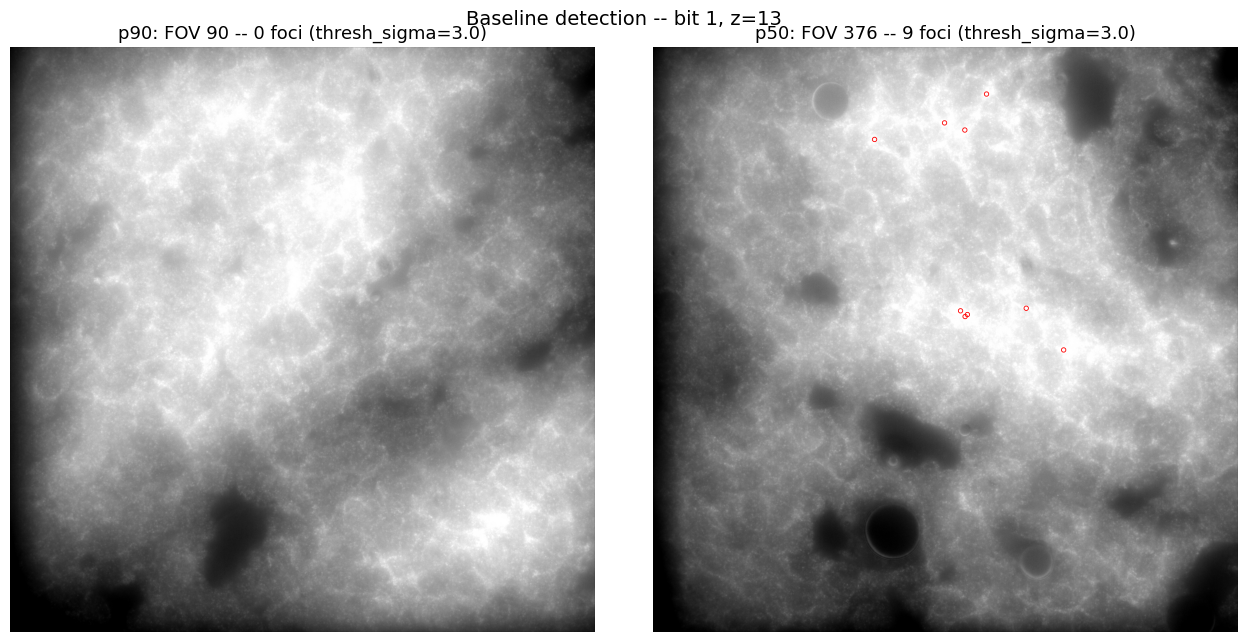

In [6]:
def detect(frame, thresh_sigma, min_dist_px=MIN_DIST_PX):
    """Same primitive as detect_beads_2d, factored so the sweep (section 7)
    doesn't redo the gaussian blur / background estimate at every threshold."""
    blurred = gaussian_filter(frame.astype(float), sigma=1.5)
    bg_mask = blurred < np.percentile(blurred, 80)
    bg_med  = np.median(blurred[bg_mask])
    bg_std  = blurred[bg_mask].std() if bg_mask.any() else 1.0
    local_mx = maximum_filter(blurred, size=int(min_dist_px)) == blurred
    thresh  = bg_med + thresh_sigma * bg_std
    candidates = np.argwhere(local_mx & (blurred > thresh))
    return candidates, bg_med

baseline_candidates = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, label in zip(axes, ["p90", "p50"]):
    frame = frames[label]
    candidates, bg_med = detect(frame, BASELINE_THRESH_SIGMA)
    baseline_candidates[label] = (candidates, bg_med)
    vmin, vmax = np.percentile(frame, [1.0, 99.0])
    ax.imshow(frame, cmap="gray", vmin=vmin, vmax=vmax)
    if len(candidates):
        ax.scatter(candidates[:, 1], candidates[:, 0], s=10, facecolors="none", edgecolors="red", linewidths=0.6)
    ax.set_title(f"{label}: FOV {target_fovs[label]} -- {len(candidates)} foci "
                 f"(thresh_sigma={BASELINE_THRESH_SIGMA})", fontsize=PLOT_TITLE_FONTSIZE)
    ax.axis("off")
fig.suptitle(f"Baseline detection -- bit {TARGET_BIT}, z={Z_PLANE}", fontsize=PLOT_TITLE_FONTSIZE + 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.baseline_overlay.png", dpi=150)
plt.show()

## 7 — Baseline spot-intensity histograms

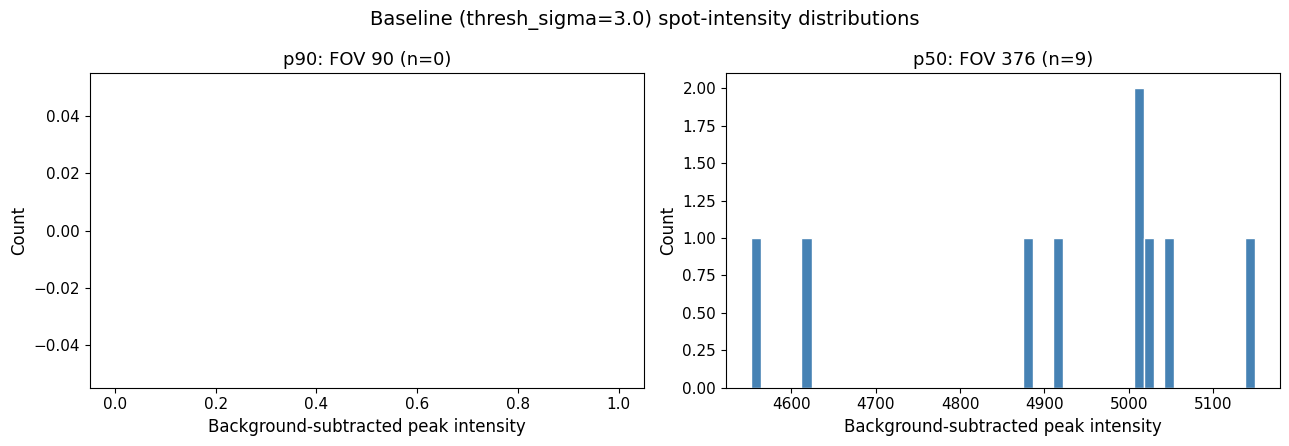

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, label in zip(axes, ["p90", "p50"]):
    frame = frames[label]
    candidates, bg_med = baseline_candidates[label]
    intensities = frame[candidates[:, 0], candidates[:, 1]] - bg_med if len(candidates) else np.array([])
    ax.hist(intensities, bins=50, color="steelblue", edgecolor="white")
    ax.set_xlabel("Background-subtracted peak intensity", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Count", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{label}: FOV {target_fovs[label]} (n={len(intensities)})", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.suptitle(f"Baseline (thresh_sigma={BASELINE_THRESH_SIGMA}) spot-intensity distributions", fontsize=PLOT_TITLE_FONTSIZE + 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.baseline_intensity_hist.png", dpi=150)
plt.show()

## 8 — Threshold sweep: foci count vs. `thresh_sigma`

Precomputes the blurred image + background estimate once per FOV (matching
`detect_beads_2d`'s own logic exactly, see `detect()` above), then just
varies the threshold -- cheap, no re-blurring per sweep point.

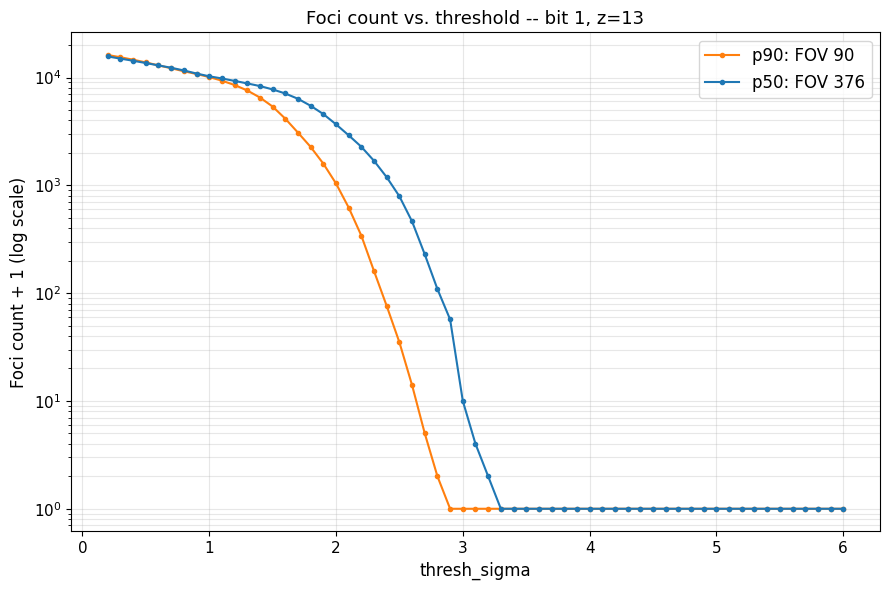

label           p50    p90
thresh_sigma              
0.2           15681  16165
0.7           12316  12191
1.2            9302   8521
1.7            6348   3082
2.2            2276    340
2.7             228      4
3.2               1      0
3.7               0      0
4.2               0      0
4.7               0      0
5.2               0      0
5.7               0      0


In [8]:
sweep_rows = []
for label in ["p90", "p50"]:
    frame = frames[label]
    blurred = gaussian_filter(frame.astype(float), sigma=1.5)
    bg_mask = blurred < np.percentile(blurred, 80)
    bg_med  = np.median(blurred[bg_mask])
    bg_std  = blurred[bg_mask].std() if bg_mask.any() else 1.0
    local_mx = maximum_filter(blurred, size=int(MIN_DIST_PX)) == blurred
    for thresh_sigma in SWEEP_THRESH_SIGMAS:
        thresh = bg_med + thresh_sigma * bg_std
        n_foci = int((local_mx & (blurred > thresh)).sum())
        sweep_rows.append({"label": label, "fov_id": target_fovs[label],
                            "thresh_sigma": float(thresh_sigma), "n_foci": n_foci})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(CACHE_DIR / "threshold_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 6))
for label, color in zip(["p90", "p50"], ["tab:orange", "tab:blue"]):
    sub = sweep_df[sweep_df["label"] == label]
    # "+1" so a true 0 count is still visible on a log axis, instead of vanishing.
    ax.plot(sub["thresh_sigma"], sub["n_foci"] + 1, "-o", ms=3, color=color,
            label=f"{label}: FOV {target_fovs[label]}")
ax.set_yscale("log")
ax.set_xlabel("thresh_sigma", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Foci count + 1 (log scale)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Foci count vs. threshold -- bit {TARGET_BIT}, z={Z_PLANE}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LABEL_FONTSIZE)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.threshold_sweep.png", dpi=150)
plt.show()

print(sweep_df.pivot(index="thresh_sigma", columns="label", values="n_foci").iloc[::5].to_string())

## 9 — Is there a usable threshold?

For both FOVs, the curve above is a **smooth, monotonic decay from ~10,000
foci (`thresh_sigma`~0.2) all the way down to exactly 0** (by `thresh_sigma`~3),
with no plateau or shoulder anywhere in between -- not the "rapid decrease
then stabilize at the real spot count" shape a genuine noise/signal mixture
would produce. A true population of discrete, above-background spots would
show up as a distinct bump the count settles onto once the noise
population has been thresholded away; here there's no such bump, only a
continuous tail down to zero.

**That means there is no `thresh_sigma` that isolates a stable, non-zero
"real spot" count on this raw, single-bit frame** -- any threshold below
~3 is still counting into the noise/autofluorescence tail, and above ~3
there's nothing left at all. This is a stronger, quantitative version of
the same conclusion `02_test_foci_density.ipynb`'s earlier sanity check
reached by eye (thousands of "foci" following cloud texture, not discrete
spots): per-bit local-maxima thresholding of a raw, non-deconvolved,
non-optimized frame is not a well-posed way to count real barcode spots on
this dataset, independent of exactly which `thresh_sigma` is chosen.

The cell below still produces the "replot at a chosen threshold" the
investigation asked for, but per the above there is no principled choice --
`thresh_sigma`~2.6 is used only because it's the last point before the
curve bottoms out to a handful of detections, so there's still something to
look at; it is **not** a validated real-spot threshold.

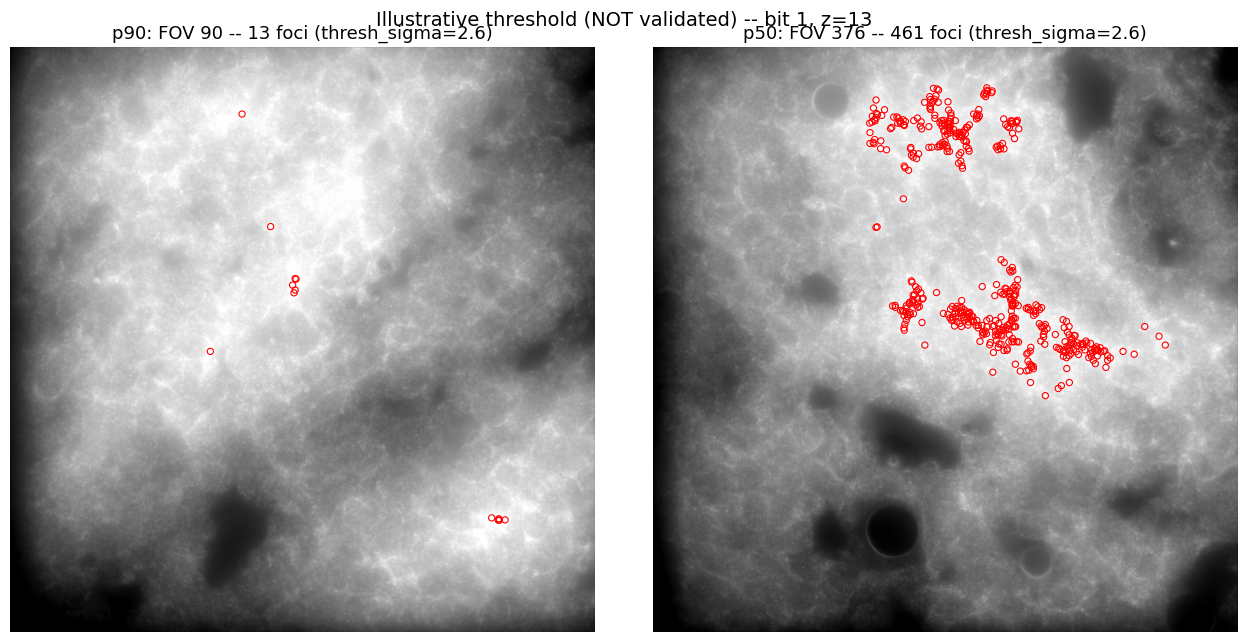

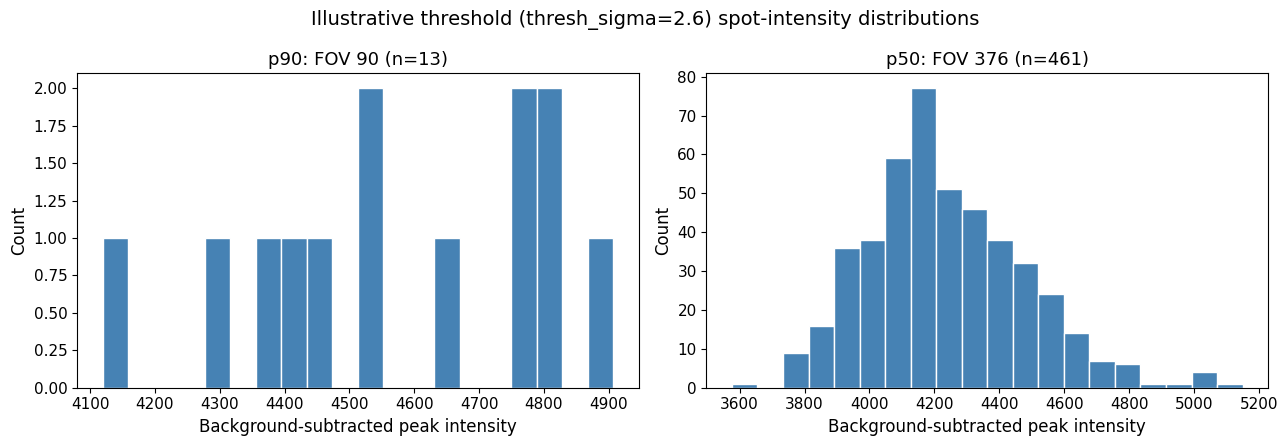

In [9]:
CHOSEN_THRESH_SIGMA = 2.6

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
chosen_candidates = {}
for ax, label in zip(axes, ["p90", "p50"]):
    frame = frames[label]
    candidates, bg_med = detect(frame, CHOSEN_THRESH_SIGMA)
    chosen_candidates[label] = (candidates, bg_med)
    vmin, vmax = np.percentile(frame, [1.0, 99.0])
    ax.imshow(frame, cmap="gray", vmin=vmin, vmax=vmax)
    if len(candidates):
        ax.scatter(candidates[:, 1], candidates[:, 0], s=20, facecolors="none", edgecolors="red", linewidths=0.8)
    ax.set_title(f"{label}: FOV {target_fovs[label]} -- {len(candidates)} foci "
                 f"(thresh_sigma={CHOSEN_THRESH_SIGMA})", fontsize=PLOT_TITLE_FONTSIZE)
    ax.axis("off")
fig.suptitle(f"Illustrative threshold (NOT validated) -- bit {TARGET_BIT}, z={Z_PLANE}", fontsize=PLOT_TITLE_FONTSIZE + 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.chosen_threshold_overlay.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, label in zip(axes, ["p90", "p50"]):
    frame = frames[label]
    candidates, bg_med = chosen_candidates[label]
    intensities = frame[candidates[:, 0], candidates[:, 1]] - bg_med if len(candidates) else np.array([])
    ax.hist(intensities, bins=20, color="steelblue", edgecolor="white")
    ax.set_xlabel("Background-subtracted peak intensity", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("Count", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_title(f"{label}: FOV {target_fovs[label]} (n={len(intensities)})", fontsize=PLOT_TITLE_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.suptitle(f"Illustrative threshold (thresh_sigma={CHOSEN_THRESH_SIGMA}) spot-intensity distributions", fontsize=PLOT_TITLE_FONTSIZE + 1)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.chosen_threshold_intensity_hist.png", dpi=150)
plt.show()